# Sensitivity and Uncertainty Analysis

This notebook visualizes the outputs under `test_run/` generated by `run_sensitivity.py`:

- Uncertainty analysis: per-week prediction intervals and means across replicates
- Sensitivity analysis: indices comparing baseline to +10% one-at-a-time perturbations
- Summary tables and saved figures for reporting

Expected inputs in `test_run/`:
- `meta.json` (run metadata)
- `config_fit.csv` (per-configuration summary: RMSE, Coverage70, mean PI width)
- `all_weekly_cases.csv` (long format: per-config, per-replicate, per-week cases)
- `sensitivity_indices.csv` (optional; will be computed if missing)

If observed data exists (path in `meta.json: obs_csv`), it will be overlaid for comparison.


In [7]:
# Imports and settings
from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150

PROJECT_ROOT = Path(".").resolve()
RUN_DIR = (PROJECT_ROOT / "test_run").resolve()
META_PATH = RUN_DIR / "meta.json"
CONFIG_FIT_PATH = RUN_DIR / "config_fit.csv"
WEEKLY_PATH = RUN_DIR / "all_weekly_cases.csv"
SENS_PATH = RUN_DIR / "sensitivity_indices.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Run dir:      {RUN_DIR}")


Project root: /home/pescuder/repast.hpc/dengue-habm-santamarta
Run dir:      /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run


In [8]:
# Load meta and observed data (if present)
meta = {}
obs_csv_path = None
obs_df = None

if META_PATH.exists():
    with open(META_PATH, "r") as f:
        meta = json.load(f)
    obs_csv_path = meta.get("obs_csv")

if obs_csv_path is None:
    # Fallback default used by run_sensitivity.py
    obs_csv_path = str(PROJECT_ROOT / "view" / "incidence_rates_santa_marta.csv")

obs_path = Path(obs_csv_path)
if obs_path.exists():
    obs_df = pd.read_csv(obs_path)
    print(f"Loaded observed data: {obs_path}")
else:
    print("Observed data not found; proceeding without overlay.")

meta


Loaded observed data: view/incidence_rates_santa_marta.csv


{'base_seed': 12345,
 'replicates': 4,
 'nominal_params': {'sigma_M': 0.3,
  'sigma_H': 3.0,
  'z': 0.3,
  'r': 0.6,
  'C': 30.0,
  'beta_mh': 0.1,
  'beta_hm': 0.1},
 'perturb_params': ['sigma_M', 'sigma_H', 'z', 'beta_mh'],
 'perturb_delta': 0.1,
 'obs_csv': 'view/incidence_rates_santa_marta.csv'}

In [9]:
# Load config_fit and weekly results
if not CONFIG_FIT_PATH.exists():
    raise FileNotFoundError(f"Missing {CONFIG_FIT_PATH}. Run aggregation first.")
if not WEEKLY_PATH.exists():
    raise FileNotFoundError(f"Missing {WEEKLY_PATH}. Run aggregation first.")

config_fit_df = pd.read_csv(CONFIG_FIT_PATH)
weekly_df = pd.read_csv(WEEKLY_PATH)

# Ensure expected columns
expected_weekly_cols = {"config_id", "replicate_id", "week", "cases"}
if not expected_weekly_cols.issubset(set(weekly_df.columns)):
    raise ValueError(f"Unexpected weekly columns: {weekly_df.columns.tolist()}")

# Basic overview
print("Configurations:", sorted(config_fit_df["config_id"].unique()))
print("Weekly rows:", len(weekly_df))
config_fit_df.head()


Configurations: ['baseline', 'beta_mh_p10', 'sigma_H_p10', 'sigma_M_p10', 'z_p10']
Weekly rows: 440


,config_id,mean_rmse,Coverage70,mean_W,n_replicates
0,baseline,120.286608,0.045455,17.668182,4
1,sigma_M_p10,121.323041,0.045455,19.813636,4
2,sigma_H_p10,121.323041,0.045455,19.813636,4
3,z_p10,338.678346,0.000000,26.109091,4
4,beta_mh_p10,151.283146,0.000000,24.913636,4


In [10]:
# Helpers to compute weekly stats per configuration

def compute_truncated_matrix_for_config(weekly_df: pd.DataFrame, config_id: str) -> Tuple[np.ndarray, List[int]]:
    """
    Build a replicate x T_star matrix of weekly cases for the given configuration.
    T_star is the minimum length across replicates.
    Returns (matrix, sorted_replicate_ids).
    """
    cdf = weekly_df[weekly_df["config_id"] == config_id].copy()
    if cdf.empty:
        return np.zeros((0, 0)), []
    # Compute replicate lengths
    rep_lengths = (cdf.groupby("replicate_id")["week"].max() + 1).astype(int)
    T_star = int(rep_lengths.min())
    replicate_ids = sorted(rep_lengths.index.tolist())

    # Initialize with NaN; we'll fill up to T_star for each replicate
    M = np.full((len(replicate_ids), T_star), np.nan, dtype=float)
    for i, rid in enumerate(replicate_ids):
        rd = cdf[cdf["replicate_id"] == rid]
        rd = rd.sort_values("week")
        # Limit to T_star weeks
        rd = rd[rd["week"] < T_star]
        weeks = rd["week"].astype(int).to_numpy()
        vals = rd["cases"].astype(float).to_numpy()
        if len(weeks) > 0:
            M[i, weeks] = vals
    return M, replicate_ids


def summarize_weekly_stats(M: np.ndarray) -> Dict[str, np.ndarray]:
    """Compute mean and 70% PI (15th, 85th percentiles) across replicates per week."""
    if M.size == 0:
        return {"mean": np.array([]), "p15": np.array([]), "p85": np.array([])}
    mean_series = np.nanmean(M, axis=0)
    p15_series = np.nanpercentile(M, 15, axis=0)
    p85_series = np.nanpercentile(M, 85, axis=0)
    return {"mean": mean_series, "p15": p15_series, "p85": p85_series}


# Pre-compute stats per config
config_ids = sorted(weekly_df["config_id"].unique())
config_stats: Dict[str, Dict[str, np.ndarray]] = {}
config_T: Dict[str, int] = {}

for cid in config_ids:
    M, rep_ids = compute_truncated_matrix_for_config(weekly_df, cid)
    stats = summarize_weekly_stats(M)
    config_stats[cid] = stats
    config_T[cid] = int(stats["mean"].shape[0]) if stats["mean"].size > 0 else 0

pd.DataFrame({"config_id": list(config_T.keys()), "T_star": list(config_T.values())})


,config_id,T_star
0,baseline,22
1,beta_mh_p10,22
2,sigma_H_p10,22
3,sigma_M_p10,22
4,z_p10,22


Saved: /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run/baseline_pi.png


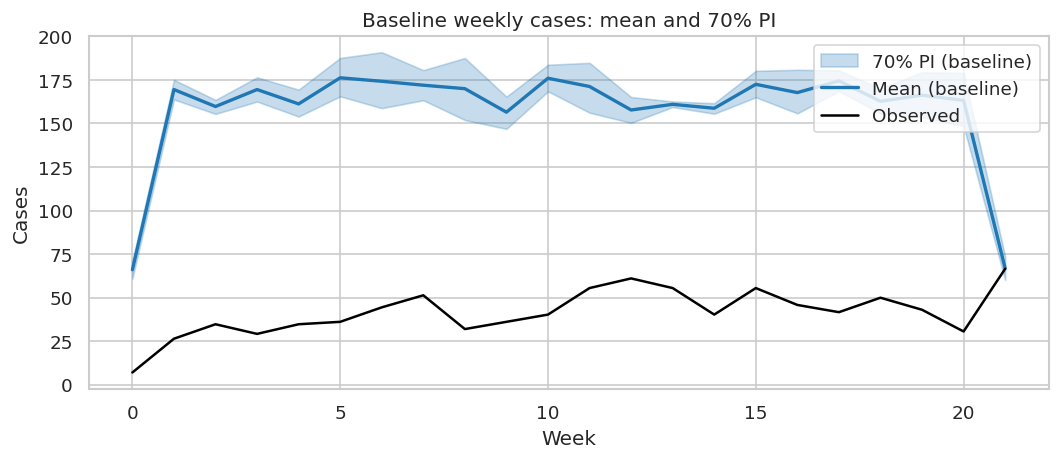

In [11]:
# Plot: Baseline PI band with mean and optional observed overlay
baseline_id = "baseline"
if baseline_id not in config_stats:
    print("Baseline configuration not found; skipping baseline plot.")
else:
    stats = config_stats[baseline_id]
    T = config_T[baseline_id]
    weeks = np.arange(T)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.fill_between(weeks, stats["p15"], stats["p85"], alpha=0.25, color="tab:blue", label="70% PI (baseline)")
    ax.plot(weeks, stats["mean"], color="tab:blue", lw=2, label="Mean (baseline)")

    # Observed overlay (if available)
    if obs_df is not None:
        # Try to locate columns
        y_col = "incidence_rate_adjusted" if "incidence_rate_adjusted" in obs_df.columns else obs_df.columns[1]
        w_col = "week" if "week" in obs_df.columns else obs_df.columns[0]
        y_obs = obs_df[y_col].to_numpy()
        w_obs = obs_df[w_col].to_numpy()
        # Align to min length
        T_plot = min(len(y_obs), T)
        ax.plot(np.arange(T_plot), y_obs[:T_plot], color="black", lw=1.5, label="Observed")

    ax.set_title("Baseline weekly cases: mean and 70% PI")
    ax.set_xlabel("Week")
    ax.set_ylabel("Cases")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig_path = RUN_DIR / "baseline_pi.png"
    fig.savefig(fig_path)
    print(f"Saved: {fig_path}")
    plt.show()


Saved: /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run/overlay_means.png


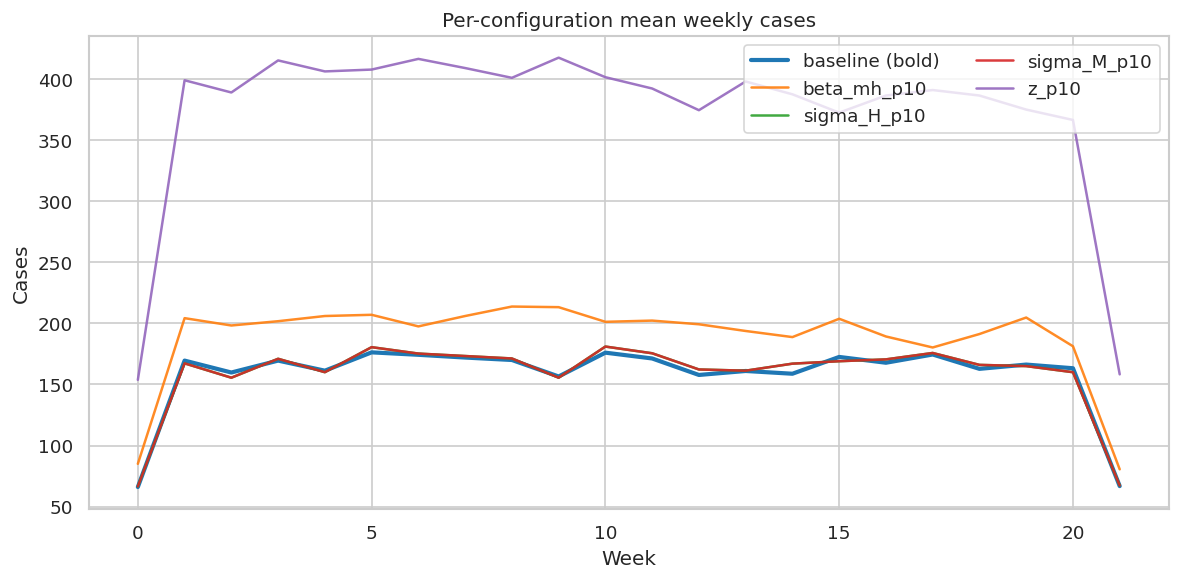

In [12]:
# Plot: Overlay means for all configurations
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("tab10", n_colors=len(config_ids))
for i, cid in enumerate(config_ids):
    stats = config_stats[cid]
    T = config_T[cid]
    if T <= 0:
        continue
    label = cid if cid != "baseline" else f"{cid} (bold)"
    lw = 2.5 if cid == "baseline" else 1.5
    alpha = 1.0 if cid == "baseline" else 0.9
    ax.plot(np.arange(T), stats["mean"], lw=lw, alpha=alpha, color=colors[i % len(colors)], label=label)

ax.set_title("Per-configuration mean weekly cases")
ax.set_xlabel("Week")
ax.set_ylabel("Cases")
ax.legend(loc="upper right", ncols=2)
fig.tight_layout()
fig_path = RUN_DIR / "overlay_means.png"
fig.savefig(fig_path)
print(f"Saved: {fig_path}")
plt.show()


Saved: /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run/pi_width_baseline.png


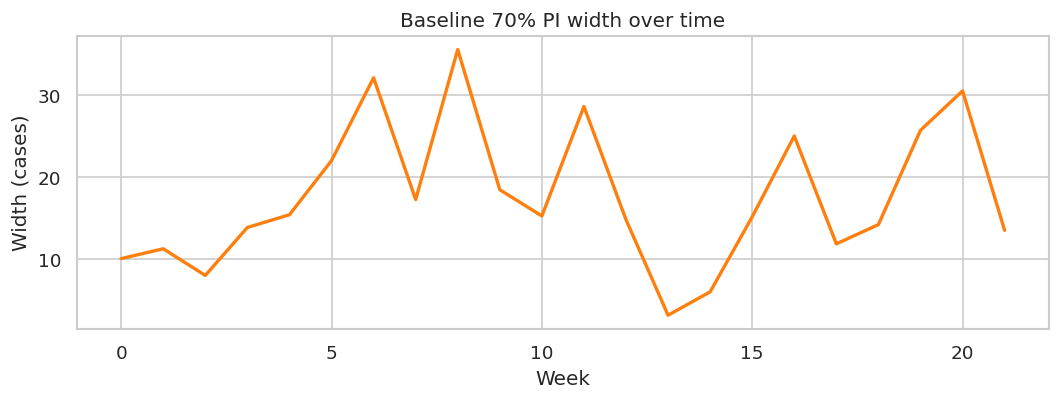

In [13]:
# Plot: Baseline PI width over time (uncertainty width)
if baseline_id in config_stats and config_T[baseline_id] > 0:
    stats = config_stats[baseline_id]
    weeks = np.arange(config_T[baseline_id])
    width = stats["p85"] - stats["p15"]

    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(weeks, width, color="tab:orange", lw=2)
    ax.set_title("Baseline 70% PI width over time")
    ax.set_xlabel("Week")
    ax.set_ylabel("Width (cases)")
    fig.tight_layout()
    fig_path = RUN_DIR / "pi_width_baseline.png"
    fig.savefig(fig_path)
    print(f"Saved: {fig_path}")
    plt.show()


Loaded sensitivity indices: /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run/sensitivity_indices.csv


,parameter,NSC,W_baseline,W_perturbed,delta_rmse,delta_cov
0,sigma_M,1.214304,17.668182,19.813636,1.036432,0.000000
1,sigma_H,1.214304,17.668182,19.813636,1.036432,0.000000
2,z,4.777463,17.668182,26.109091,218.391738,-0.045455
3,beta_mh,4.100849,17.668182,24.913636,30.996537,-0.045455


Saved: /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run/sensitivity_nsc.png


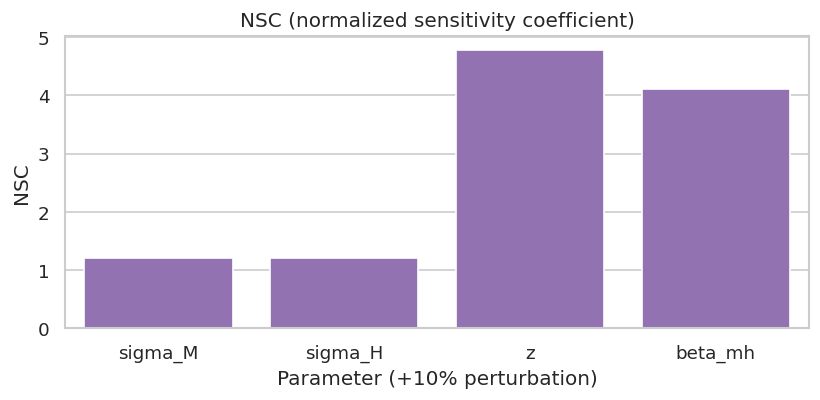

Saved: /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run/sensitivity_deltas.png


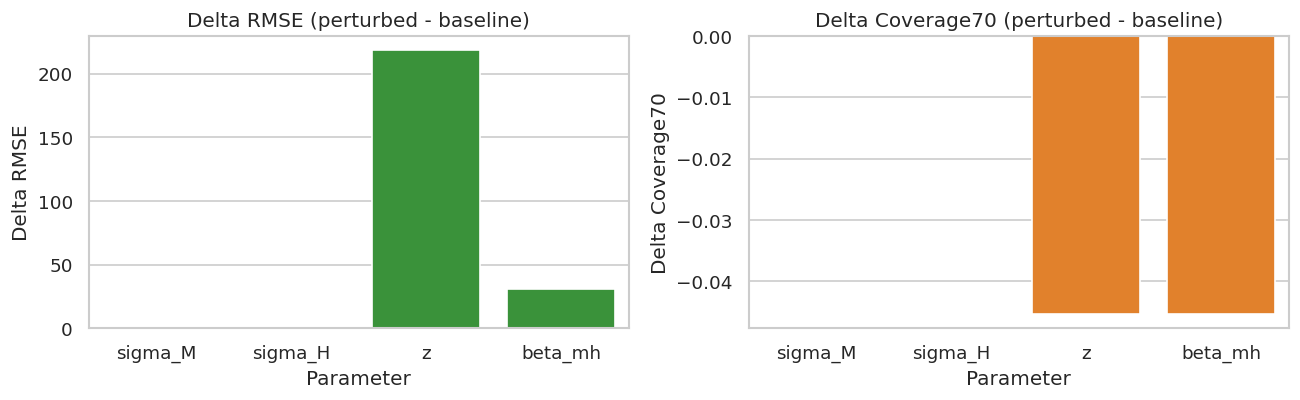

In [14]:
# Sensitivity indices: load if present, otherwise compute from config_fit
sens_df = None
if SENS_PATH.exists():
    sens_df = pd.read_csv(SENS_PATH)
    print(f"Loaded sensitivity indices: {SENS_PATH}")
else:
    # Recompute following run_sensitivity.py logic
    cfg = config_fit_df.set_index("config_id")
    if "baseline" in cfg.index:
        W_b = cfg.loc["baseline", "mean_W"]
        rmse_b = cfg.loc["baseline", "mean_rmse"]
        cov_b = cfg.loc["baseline", "Coverage70"] if "Coverage70" in cfg.columns else np.nan

        # Default perturb params and delta per run_sensitivity.py
        perturb_params = meta.get("perturb_params", ["sigma_M", "sigma_H", "z", "beta_mh"])
        perturb_delta = float(meta.get("perturb_delta", 0.10))

        records = []
        for p in perturb_params:
            pid = f"{p}_p10"
            if pid in cfg.index:
                W_p = cfg.loc[pid, "mean_W"]
                rmse_p = cfg.loc[pid, "mean_rmse"]
                cov_p = cfg.loc[pid, "Coverage70"] if "Coverage70" in cfg.columns else np.nan
                nsc = ((W_p - W_b) / W_b) / perturb_delta if (W_b > 0) else np.nan
                delta_rmse = rmse_p - rmse_b
                delta_cov = (cov_p - cov_b) if (not np.isnan(cov_p) and not np.isnan(cov_b)) else np.nan
                records.append({
                    "parameter": p,
                    "NSC": nsc,
                    "W_baseline": W_b,
                    "W_perturbed": W_p,
                    "delta_rmse": delta_rmse,
                    "delta_cov": delta_cov,
                })
        sens_df = pd.DataFrame.from_records(records)

if sens_df is None or sens_df.empty:
    print("No sensitivity indices available.")
else:
    display(sens_df)

    # Plot NSC bar chart
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.barplot(sens_df, x="parameter", y="NSC", color="tab:purple", ax=ax)
    ax.set_title("NSC (normalized sensitivity coefficient)")
    ax.set_xlabel("Parameter (+10% perturbation)")
    ax.set_ylabel("NSC")
    fig.tight_layout()
    fig_path = RUN_DIR / "sensitivity_nsc.png"
    fig.savefig(fig_path)
    print(f"Saved: {fig_path}")
    plt.show()

    # Plot delta RMSE and delta Coverage
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
    sns.barplot(sens_df, x="parameter", y="delta_rmse", color="tab:green", ax=axs[0])
    axs[0].set_title("Delta RMSE (perturbed - baseline)")
    axs[0].set_xlabel("Parameter")
    axs[0].set_ylabel("Delta RMSE")

    sns.barplot(sens_df, x="parameter", y="delta_cov", color="tab:orange", ax=axs[1])
    axs[1].set_title("Delta Coverage70 (perturbed - baseline)")
    axs[1].set_xlabel("Parameter")
    axs[1].set_ylabel("Delta Coverage70")

    fig.tight_layout()
    fig_path = RUN_DIR / "sensitivity_deltas.png"
    fig.savefig(fig_path)
    print(f"Saved: {fig_path}")
    plt.show()


In [15]:
# Save summary tables and display quick views
# Config fit summary
config_fit_out = RUN_DIR / "config_fit_summary.csv"
config_fit_df.to_csv(config_fit_out, index=False)
print(f"Saved: {config_fit_out}")
display(config_fit_df.sort_values("config_id"))

# Sensitivity indices table (if available)
if 'sens_df' in globals() and sens_df is not None and not sens_df.empty:
    sens_out = RUN_DIR / "sensitivity_indices.csv"
    sens_df.to_csv(sens_out, index=False)
    print(f"Saved: {sens_out}")
    display(sens_df.sort_values("parameter"))


Saved: /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run/config_fit_summary.csv


,config_id,mean_rmse,Coverage70,mean_W,n_replicates
0,baseline,120.286608,0.045455,17.668182,4
4,beta_mh_p10,151.283146,0.000000,24.913636,4
2,sigma_H_p10,121.323041,0.045455,19.813636,4
1,sigma_M_p10,121.323041,0.045455,19.813636,4
3,z_p10,338.678346,0.000000,26.109091,4


Saved: /home/pescuder/repast.hpc/dengue-habm-santamarta/test_run/sensitivity_indices.csv


,parameter,NSC,W_baseline,W_perturbed,delta_rmse,delta_cov
3,beta_mh,4.100849,17.668182,24.913636,30.996537,-0.045455
1,sigma_H,1.214304,17.668182,19.813636,1.036432,0.000000
0,sigma_M,1.214304,17.668182,19.813636,1.036432,0.000000
2,z,4.777463,17.668182,26.109091,218.391738,-0.045455
